# Models comparison: Global-View (target scale)

Scenarios: ['clasp_factoring', 'saps-CVVAR', 'spear_qcp', 'yalsat_qcp', 'spear_swgcp', 'yalsat_swgcp', 'lpg-zeno']
Context sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
Models: ['tabpfn_original', 'tabpfn_log']
Total aggregated entries: 728


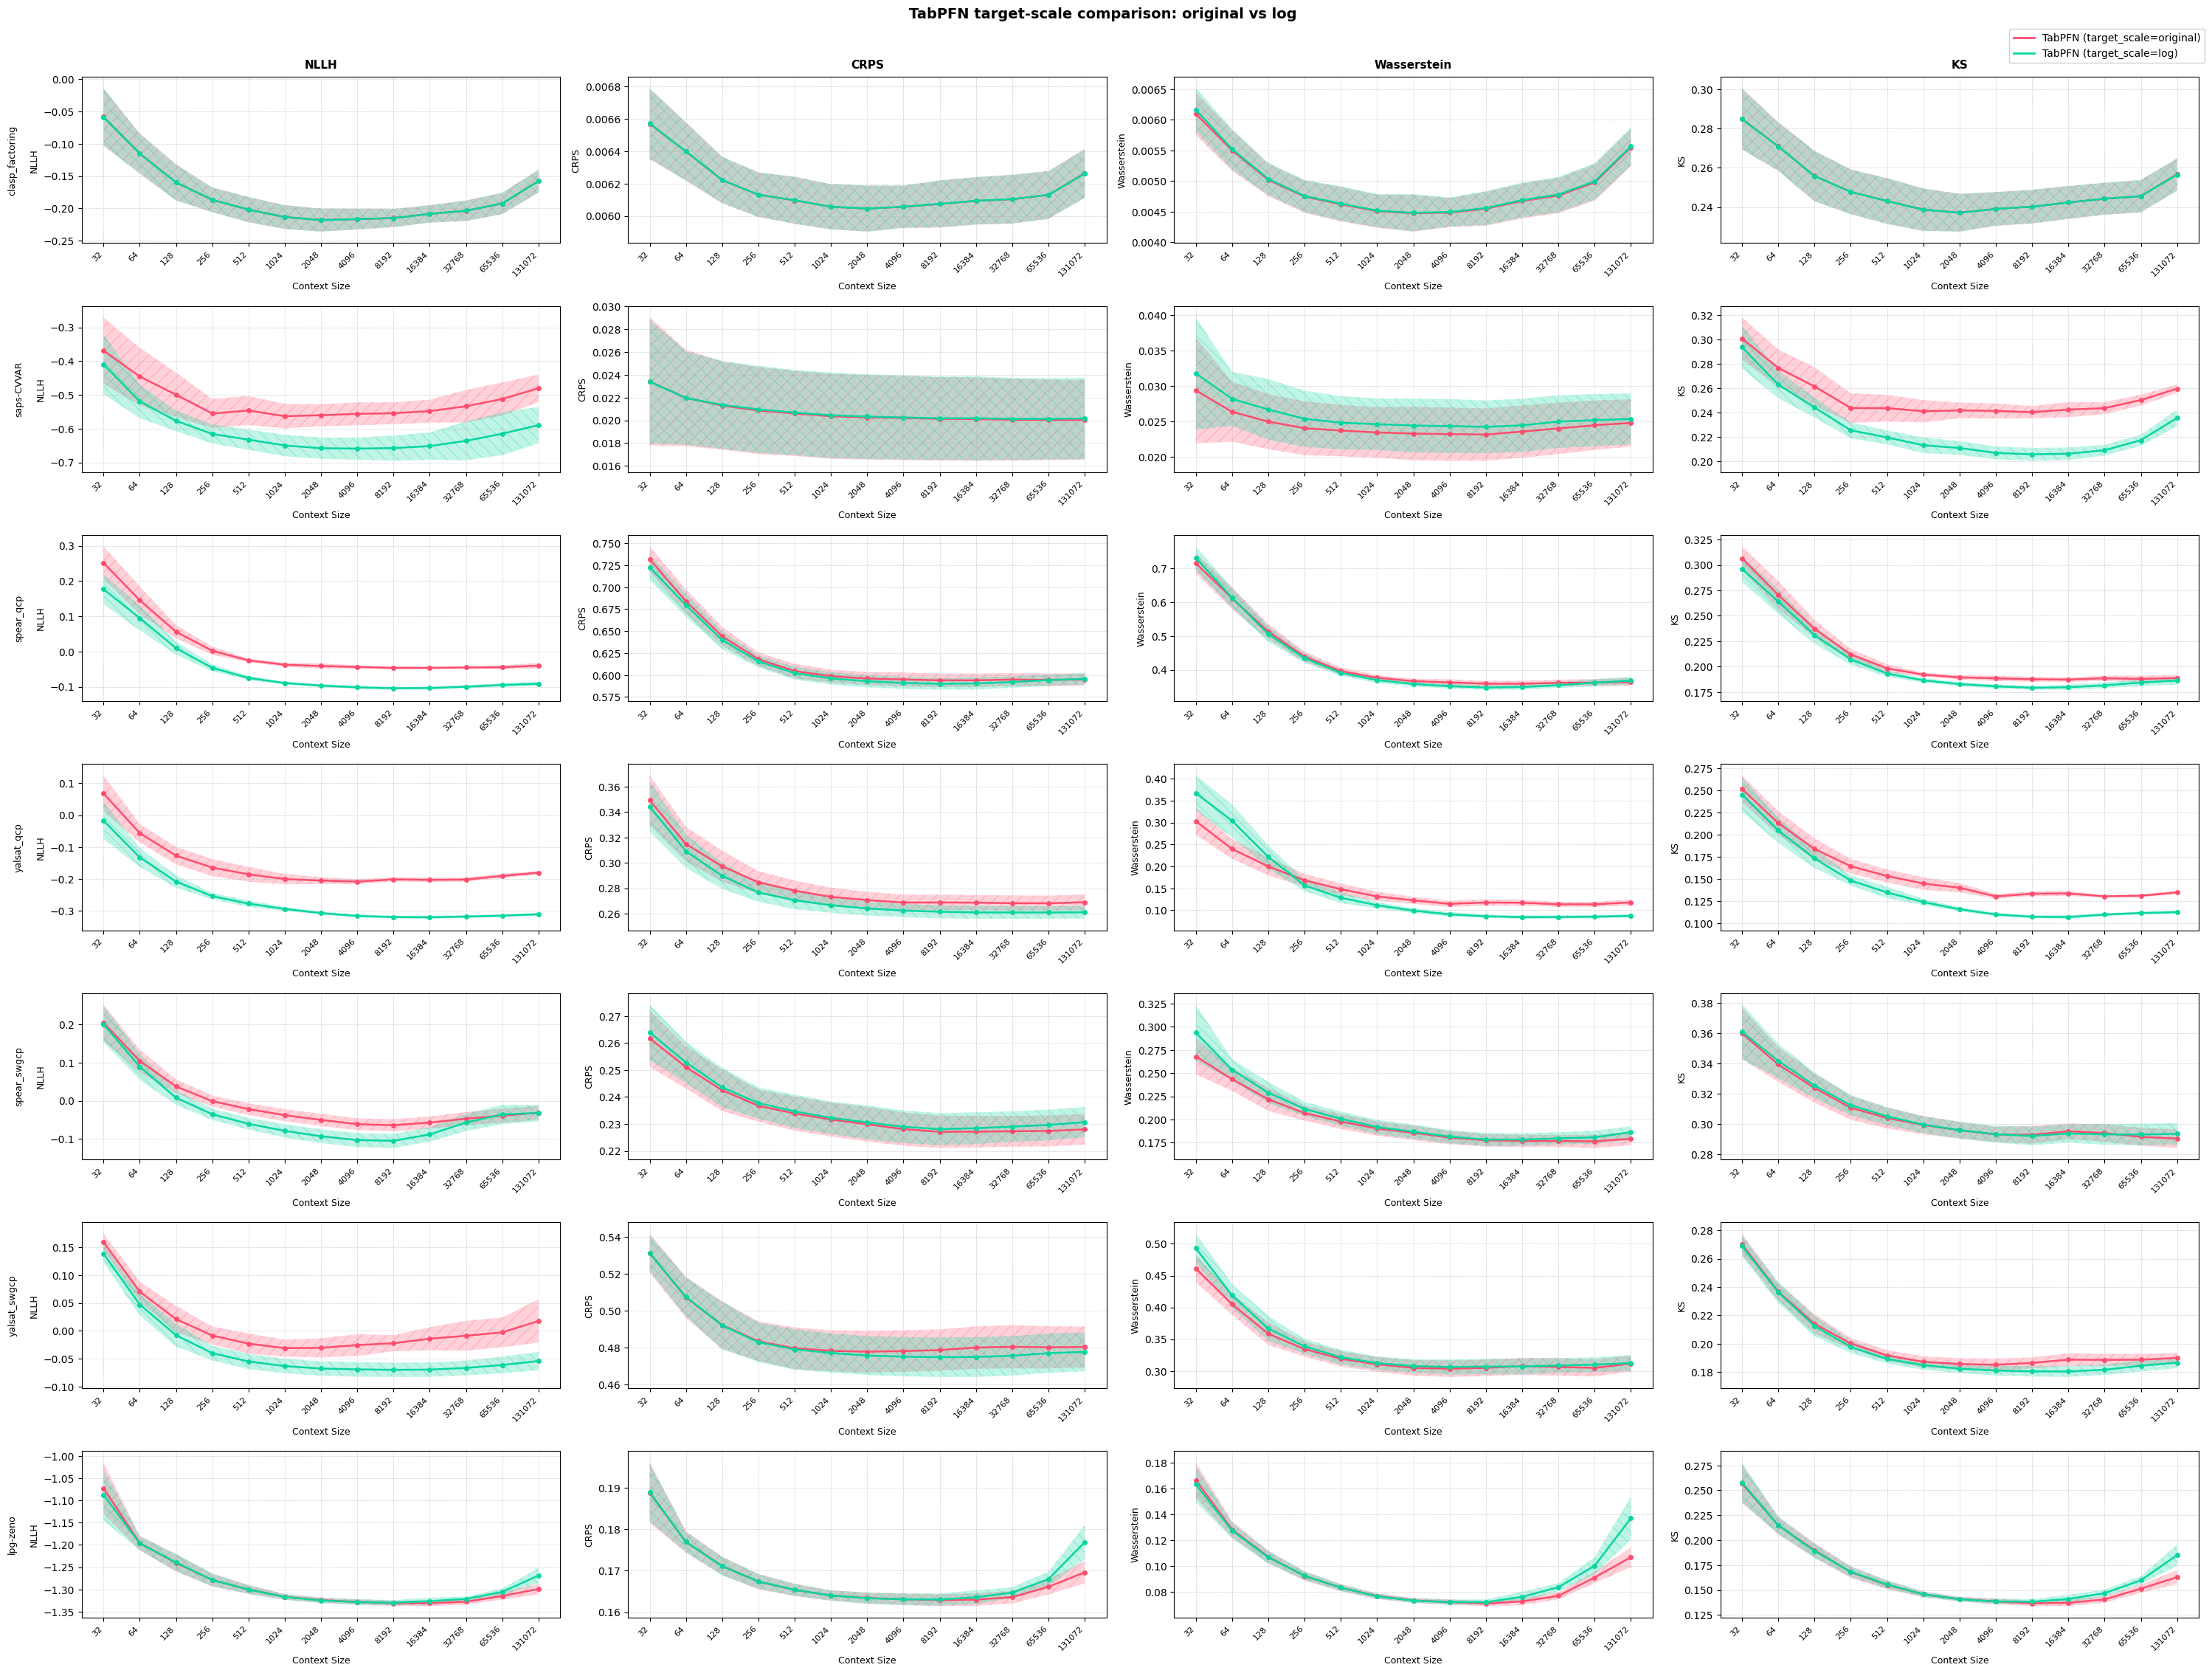

In [1]:
from collections import defaultdict
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from tabpfn_project.globals import DISTNET_SCENARIOS
from tabpfn_project.paths import RESULTS_DIR

results_dir = RESULTS_DIR / "experiment_scaler_effect"

tabpfn_log_results_path = results_dir / "tabpfn_target_scale_log_all_scenarios.pkl"
tabpfn_original_results_path = results_dir / "tabpfn_target_scale_original_all_scenarios.pkl"

with open(tabpfn_log_results_path, "rb") as f:
    tabpfn_log_results = pickle.load(f)

with open(tabpfn_original_results_path, "rb") as f:
    tabpfn_original_results = pickle.load(f)

all_results = []
for entry in tabpfn_original_results:
    enriched = dict(entry)
    enriched["model"] = "tabpfn_original"
    all_results.append(enriched)

for entry in tabpfn_log_results:
    enriched = dict(entry)
    enriched["model"] = "tabpfn_log"
    all_results.append(enriched)

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# ------------------------------------------------------------------
# Aggregation strategy (same as in experiment_context_size.ipynb):
# 1) For each (model, scenario, context_size, fold), average over seeds
# 2) For each (model, scenario, context_size), average over folds
# 3) Shade with std across folds
# ------------------------------------------------------------------

# (model, scenario, context_size, fold, metric) -> list of seed-level run scores
seed_scores_by_fold = defaultdict(list)

for entry in all_results:
    model = entry["model"]
    scenario = entry["scenario"]
    context_size = entry["context_size"]
    fold = entry["fold"]
    inst_summ = entry["instance_summary"]

    for metric in METRICS:
        vals = inst_summ[metric]
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()

        # One score per seed-run: mean over instances
        run_score = float(vals.mean())
        seed_scores_by_fold[(model, scenario, context_size, fold, metric)].append(run_score)

# (model, scenario, context_size, metric) -> list of fold means
fold_means = defaultdict(list)

for key, seed_scores in seed_scores_by_fold.items():
    model, scenario, context_size, fold, metric = key
    fold_mean = float(np.mean(seed_scores))
    fold_means[(model, scenario, context_size, metric)].append(fold_mean)

# Final plot data: mean/std over folds
plot_data = {}
for key, fold_scores in fold_means.items():
    scores = np.asarray(fold_scores, dtype=float)
    mean_over_folds = float(np.mean(scores))
    std_over_folds = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
    plot_data[key] = (mean_over_folds, std_over_folds, len(scores))

# Keep all known scenarios visible (7 rows expected)
scenarios = list(DISTNET_SCENARIOS)
context_sizes = sorted({k[2] for k in plot_data.keys()})
models = ["tabpfn_original", "tabpfn_log"]

print(f"Scenarios: {scenarios}")
print(f"Context sizes: {context_sizes}")
print(f"Models: {models}")
print(f"Total aggregated entries: {len(plot_data)}")


MODEL_COLORS = {"tabpfn_original": "#FF4D6D", "tabpfn_log": "#06D6A0"}
MODEL_HATCHES = {"tabpfn_original": "//", "tabpfn_log": "\\\\"}
MODEL_LABELS = {"tabpfn_original": "TabPFN (target_scale=original)", "tabpfn_log": "TabPFN (target_scale=log)"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}

# Show every context size on the x-axis (log scale).
x_ticks = context_sizes

n_rows = len(scenarios)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7.5 * n_cols, 3.2 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        for model in models:
            xs, means, stds = [], [], []
            for cs in context_sizes:
                key = (model, scenario, cs, metric)
                if key in plot_data:
                    m, s, n_folds = plot_data[key]
                    xs.append(cs)
                    means.append(m)
                    stds.append(s)

            if not xs:
                continue

            xs = np.array(xs, dtype=float)
            means = np.array(means, dtype=float)
            stds = np.array(stds, dtype=float)

            color = MODEL_COLORS[model]
            hatch = MODEL_HATCHES[model]
            ax.plot(
                xs,
                means,
                marker="o",
                markersize=4,
                linewidth=1.8,
                color=color,
                label=MODEL_LABELS[model],
            )
            ax.fill_between(xs, means - stds, means + stds, alpha=0.25, color=color, hatch=hatch, edgecolor=color, linewidth=0)

        ax.set_xscale("log", base=2)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(cs) for cs in x_ticks], rotation=45, ha="right", fontsize=8)

        ax.margins(y=0.08)
        ax.set_xlabel("Context Size", fontsize=9)

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario}\n\n{METRIC_LABELS[metric]}",
                fontsize=9,
            )
        else:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

# Shared legend
handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2, label=MODEL_LABELS[m])
    for m in models
]
fig.legend(
    handles=handles,
    loc="upper right",
    fontsize=10,
    framealpha=0.9,
    bbox_to_anchor=(1.0, 1.0),
)

plt.suptitle(
    "TabPFN target-scale comparison: original vs log",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

# Save aggregated results as CSV

In [2]:
import pandas as pd

# 1) Full aggregated table used for plotting.
rows = []
for model in models:
    for scenario in scenarios:
        for metric in METRICS:
            for context_size in context_sizes:
                key = (model, scenario, context_size, metric)
                if key not in plot_data:
                    continue
                mean_over_folds, std_over_folds, n_folds = plot_data[key]
                rows.append(
                    {
                        "model": model,
                        "model_label": MODEL_LABELS.get(model, model),
                        "scenario": scenario,
                        "metric": metric,
                        "context_size": int(context_size),
                        "mean_over_folds": float(mean_over_folds),
                        "std_over_folds": float(std_over_folds),
                        "n_folds": int(n_folds),
                    }
                )

agg_df = pd.DataFrame(rows).sort_values(["scenario", "metric", "model", "context_size"])

# 2) Best row per (scenario, metric), considering all models and all context sizes.
best_rows = []
for scenario in scenarios:
    for metric in METRICS:
        block = agg_df[(agg_df["scenario"] == scenario) & (agg_df["metric"] == metric)].copy()
        if block.empty:
            continue

        block = block.sort_values(["mean_over_folds", "context_size"], ascending=[True, True])
        best = block.iloc[0]
        best_rows.append(
            {
                "scenario": scenario,
                "metric": metric,
                "best_model": best["model"],
                "best_model_label": best["model_label"],
                "best_context_size": int(best["context_size"]),
                "best_mean_over_folds": float(best["mean_over_folds"]),
                "best_std_over_folds": float(best["std_over_folds"]),
                "best_n_folds": int(best["n_folds"]),
            }
        )

best_df = pd.DataFrame(best_rows).sort_values(["scenario", "metric"])

# 3) Save publication-ready CSV files.
out_full = results_dir / "scaler_effect_aggregated_scores.csv"
out_best = results_dir / "scaler_effect_best_points_all_scenarios.csv"

agg_df.to_csv(out_full, index=False)
best_df.to_csv(out_best, index=False)

print(f"Saved full aggregated table: {out_full} ({len(agg_df)} rows)")
print(f"Saved best-points table: {out_best} ({len(best_df)} rows)")

Saved full aggregated table: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_scaler_effect\scaler_effect_aggregated_scores.csv (728 rows)
Saved best-points table: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_scaler_effect\scaler_effect_best_points_all_scenarios.csv (28 rows)
